# Gender Prediction using Last Letter of Name with Naive Bayes (No Vectorizer)

We will predict gender using only the **last character of the name** as input.  
Instead of CountVectorizer, we directly encode the last letter as a categorical feature.

In [18]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

## 📌 Step 2: Load Dataset

In [2]:
df = pd.read_csv("GenderPrediction_data.csv")

## 📌 Step 3: Train-Validation Split (Stratified)

In [3]:
train_df, val_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df["Gender"]
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 2099
Validation size: 900


## 📊 Step 4: Gender Distribution in Train and Validation

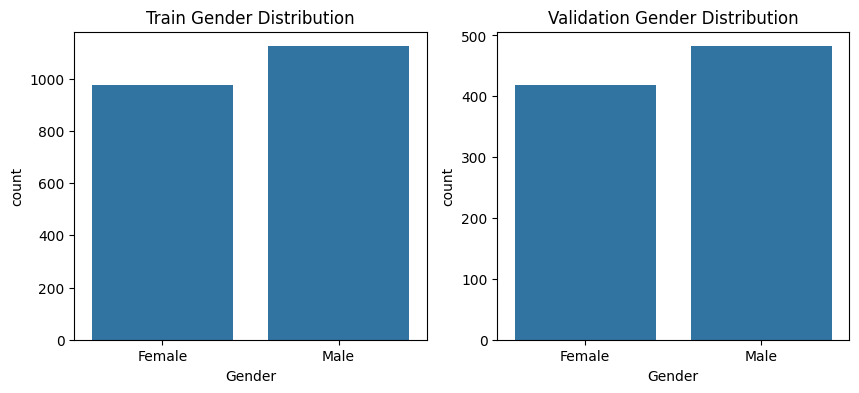

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.countplot(x="Gender", data=train_df, ax=axes[0])
axes[0].set_title("Train Gender Distribution")

sns.countplot(x="Gender", data=val_df, ax=axes[1])
axes[1].set_title("Validation Gender Distribution")

plt.show()

## 📌 Step 5: Feature Engineering → Last Letter

In [5]:
train_df["last_letter"] = train_df["Name"].str.strip().str.lower().str[-1]
val_df["last_letter"] = val_df["Name"].str.strip().str.lower().str[-1]

## 📌 Step 6: Encode Labels (Gender + Last Letter)

In [30]:
X_train.todense()

matrix([[1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]], shape=(2099, 23))

In [28]:
# One-Hot Encode last_letter
ohe = OneHotEncoder(handle_unknown="ignore")

X_train = ohe.fit_transform(train_df[["last_letter"]])
X_val   = ohe.transform(val_df[["last_letter"]])

y_train = train_df["Gender"]
y_val   = val_df["Gender"]

print("Shape of One-Hot Encoded X_train:", X_train.shape)
print("Example row:\n", X_train[0])


Shape of One-Hot Encoded X_train: (2099, 23)
Example row:
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1 stored elements and shape (1, 23)>
  Coords	Values
  (0, 0)	1.0


## 📌 Step 7: Train Naive Bayes (MultinomialNB)

In [7]:
model = BernoulliNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

## Let's Check our Model Accuracy

In [8]:
# Predict on validation set
y_val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy: {val_acc:.3f}")

Validation Accuracy: 0.829


## 📊 Step 8: Model Evaluation

              precision    recall  f1-score   support

      Female       0.77      0.91      0.83       418
        Male       0.91      0.76      0.83       482

    accuracy                           0.83       900
   macro avg       0.84      0.83      0.83       900
weighted avg       0.84      0.83      0.83       900



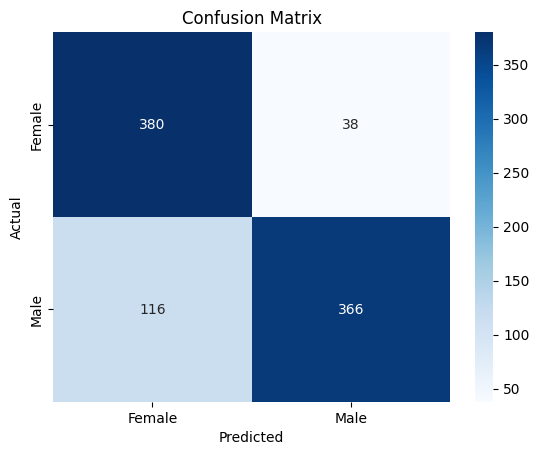

In [9]:
print(classification_report(y_val, y_pred))

labels = ["Female", "Male"] 
cm = confusion_matrix(y_val, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [10]:
def predict_gender(name):
    # take last letter
    last_letter = name.strip().lower()[-1]
    
    # put it in a DataFrame with the same column name used in fit (say 'last_letter')
    enc_letter = ohe.transform(pd.DataFrame([[last_letter]], columns=['last_letter']))
    
    # predict gender
    pred = model.predict(enc_letter)[0]
    
    # get probabilities
    prob = model.predict_proba(enc_letter)[0]
    prob_dict = dict(zip(model.classes_, prob.round(3)))
    
    return pred, prob_dict


# Try on some names
test_names = ["Kirti", "Seema", "Vikas", "Priya", "Aman"]
for n in test_names:
    pred, probs = predict_gender(n)
    print(f"{n} → {pred}, Probabilities: {probs}")

Kirti → Female, Probabilities: {np.str_('Female'): np.float64(0.827), np.str_('Male'): np.float64(0.173)}
Seema → Female, Probabilities: {np.str_('Female'): np.float64(0.789), np.str_('Male'): np.float64(0.211)}
Vikas → Male, Probabilities: {np.str_('Female'): np.float64(0.142), np.str_('Male'): np.float64(0.858)}
Priya → Female, Probabilities: {np.str_('Female'): np.float64(0.789), np.str_('Male'): np.float64(0.211)}
Aman → Male, Probabilities: {np.str_('Female'): np.float64(0.049), np.str_('Male'): np.float64(0.951)}


## Let's check if the model is overfitting or underfitting

In [11]:
# Predict on training set
y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

# Predict on validation set
y_val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Validation Accuracy: {val_acc:.3f}")


Training Accuracy: 0.822
Validation Accuracy: 0.829


## Yayy ! Our model is not overfitting

# Is this the final verdict or we can do better?

# Let's learn cross validation and grid search now for better results

In [12]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Take last letter as feature
X_train = df["Name"].apply(lambda x: str(x).lower()[-1]).values.reshape(-1, 1)
y_train = df["Gender"]

# One-hot encode last letters
ohe = OneHotEncoder(handle_unknown="ignore")
X_train_enc = ohe.fit_transform(X_train)

# Stratified K-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Parameter grid for MultinomialNB
param_grid = {
    'alpha': [0.00001, 0.01, 0.1, 0.5, 1.0, 2.0]
}

# Grid search with F1 score
grid = GridSearchCV(
    BernoulliNB(),
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train_enc, y_train)

print("Best Parameters:", grid.best_params_)
print("Best F1 Score (CV):", grid.best_score_)


Best Parameters: {'alpha': 1e-05}
Best F1 Score (CV): 0.8241999304553016


# Let's see how the misclassified examples look like

In [15]:
import pandas as pd

# Get the best model
best_model = grid.best_estimator_

# Predict on training data
y_pred = best_model.predict(X_train_enc)

# Find misclassified examples
misclassified_idx = np.where(y_pred != y_train)[0]

# Create DataFrame of misclassified examples
misclassified_df = pd.DataFrame({
    "Name": df["Name"].iloc[misclassified_idx].values,
    "Actual": y_train.iloc[misclassified_idx].values,
    "Predicted": y_pred[misclassified_idx]
})

print("Total misclassified:", len(misclassified_df))
print(misclassified_df.head(20))  # show first 20 misclassified


Total misclassified: 527
            Name  Actual Predicted
0     Abhicandra    Male    Female
1     Mahajabeen  Female      Male
2     Devadyumna    Male    Female
3          Rupal  Female      Male
4      Acalapati    Male    Female
5         Agneya    Male    Female
6         Punita    Male    Female
7          Mrudu  Female      Male
8   Radhakrishna    Male    Female
9    Kunjabihari    Male    Female
10        Arghya    Male    Female
11      Khushboo  Female      Male
12          Ayeh  Female      Male
13   Jagachandra    Male    Female
14          Ritu  Female      Male
15     Subramani    Male    Female
16      Nithilam  Female      Male
17     Vedavrata    Male    Female
18      Ekalavya    Male    Female
19       Chumban  Female      Male



## 🔤 Extending Gender Prediction with Last 2 Letters

Instead of using only the last letter of the name, we can improve our model by considering the last **1, 2, and 3 letters** of names.  
This allows the model to capture richer patterns 
Fix: Look at last two letters instead:

-ra, -na, -ya, -ta → often Male <br>
-aa, -ita, -ita, -ini → often Female


In [20]:
X_train = df["Name"].apply(lambda x: str(x).lower()[-2:])
y_train = df["Gender"]

# Define pipeline (vectorizer + classifier)
pipe = Pipeline([
    ('vectorizer', CountVectorizer(analyzer="char")),
    ('nb', BernoulliNB())
])

# Define parameter grid
param_grid = {
    'vectorizer__ngram_range': [(1,1), (1,2)],
    'nb__alpha': [0.1, 0.5, 1.0, 2.0]
}

# Grid search with F1 score optimization
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best F1 Score (CV):", grid.best_score_)

Best Parameters: {'nb__alpha': 0.5, 'vectorizer__ngram_range': (1, 2)}
Best F1 Score (CV): 0.8216293707780622


## Its ok !! No Improvement found. What else can be done? Let's take first and last letter

In [26]:
# Correct ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("first1_vect", CountVectorizer(analyzer="char", ngram_range=(1,1)), "first1"),
        ("last1_vect",  CountVectorizer(analyzer="char", ngram_range=(1,1)), "last1"),
    ]
)

# Pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('to_dense', FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
    ('nb', BernoulliNB())
])

# Parameter grid
param_grid = {
    'preprocessor__first1_vect__ngram_range': [(1,1)],
    'preprocessor__last1_vect__ngram_range':  [(1,1)],
    'nb__alpha': [0.01, 0.1, 0.5, 1.0]
}

# Stratified K-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
grid.fit(X_features, y)

print("Best Parameters:", grid.best_params_)
print("Best F1 Score (CV):", grid.best_score_)


Best Parameters: {'nb__alpha': 0.01, 'preprocessor__first1_vect__ngram_range': (1, 1), 'preprocessor__last1_vect__ngram_range': (1, 1)}
Best F1 Score (CV): 0.8235163722785185
